# Week 5: Comprehensive Data Science Project

## Fake Job Posting Detection

### Project Objective

Develop an end-to-end data science workflow for analyzing and predicting fraudulent job postings.

### Project Stages

1. Data Acquisition
2. Data Cleaning
3. Exploratory Data Analysis
4. Advanced Data Visualization
5. Statistical Analysis
6. Hypothesis Testing
7. Machine Learning
8. Model Evaluation
9. Strategic Recommendations
10. Future Improvements

Step 1 — Import libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Step 2 — Load your dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/cleaned_fake_job_postings.csv")

df = df.dropna(subset=["fraudulent"]).copy()
df["fraudulent"] = df["fraudulent"].astype(int)

print("Dataset Shape:", df.shape)ā

Dataset Shape: (6840, 19)


# Step 3 — Final dataset overview

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Dataset Shape: (6840, 19)

Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'description_length']

Missing Values:
job_id                    0
title                     0
location                123
department             4321
salary_range           5761
company_profile        1517
description               0
requirements            934
benefits               2738
telecommuting             0
has_company_logo          0
has_questions             0
employment_type        1646
required_experience    2808
required_education     3121
industry               2061
function               2558
fraudulent                0
description_length        0
dtype: int64

Duplicate Records:
0


# Step 4 — Target distribution

In [ ]:
print(df['fraudulent'].value_counts())

print("\nTarget Percentage:")
print(df['fraudulent'].value_counts(normalize=True) * 100)

fraudulent
0    6525
1     315
Name: count, dtype: int64

Target Percentage:
fraudulent
0    95.394737
1     4.605263
Name: proportion, dtype: float64


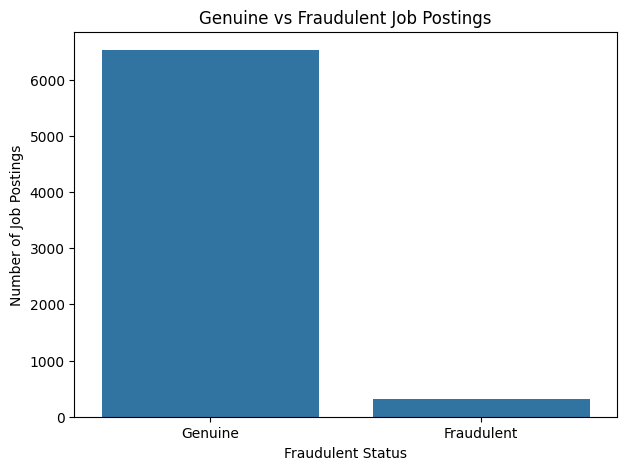

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='fraudulent')

plt.title('Genuine vs Fraudulent Job Postings')
plt.xlabel('Fraudulent Status')
plt.ylabel('Number of Job Postings')
plt.xticks([0, 1], ['Genuine', 'Fraudulent'])

plt.show()

Step 5 — Final fraud analysis by company logo

In [ ]:
logo_fraud = pd.crosstab(
    df['has_company_logo'],
    df['fraudulent'],
    normalize='index'
) * 100

logo_fraud

fraudulent,0,1
has_company_logo,,
0,87.845659,12.154341
1,97.615894,2.384106


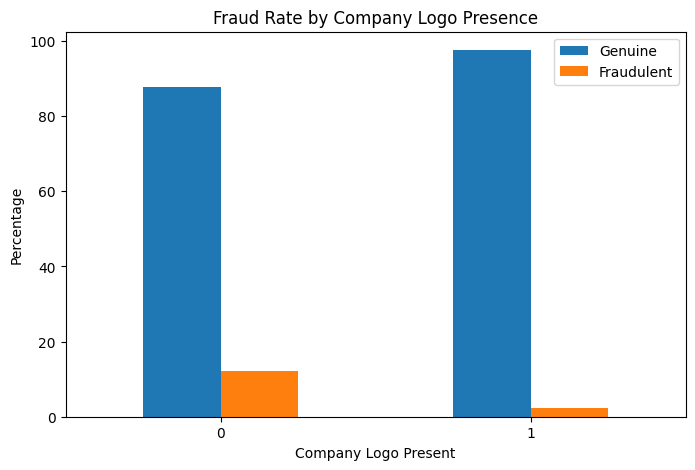

In [ ]:
logo_fraud.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Fraud Rate by Company Logo Presence')
plt.xlabel('Company Logo Present')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['Genuine', 'Fraudulent'])

plt.show()

Step 6 — Statistical analysis

In [ ]:
contingency_table = pd.crosstab(
    df['has_company_logo'],
    df['fraudulent']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 258.8468469536185
p-value: 3.061103938367776e-58
Degrees of Freedom: 1


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("There is a statistically significant association.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("There is no statistically significant association.")

Result: Reject the Null Hypothesis.
There is a statistically significant association.


# Step 7 — Final machine learning model

In [ ]:
features = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'employment_type',
    'required_experience',
    'required_education',
    'description_length'
]

X = df[features]
y = df['fraudulent'].astype(int)

In [ ]:
numerical_features = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'description_length'
]

categorical_features = [
    'employment_type',
    'required_experience',
    'required_education'
]

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 8 — Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5472, 7)
Testing Data: (1368, 7)


# Step 9 — Train Logistic Regression

In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# Step 10 — Predictions

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# Step 11 — Calculate final metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7448830409356725
Precision: 0.11764705882352941
Recall   : 0.6984126984126984
F1-Score : 0.20137299771167047
ROC-AUC  : 0.8206349206349207


# Step 12 — Final performance table

In [ ]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.744883
1,Precision,0.117647
2,Recall,0.698413
3,F1-Score,0.201373
4,ROC-AUC,0.820635


# Step 13 — Classification report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Genuine', 'Fraudulent'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.98      0.75      0.85      1305
  Fraudulent       0.12      0.70      0.20        63

    accuracy                           0.74      1368
   macro avg       0.55      0.72      0.52      1368
weighted avg       0.94      0.74      0.82      1368



# Step 14 — Final confusion matrix

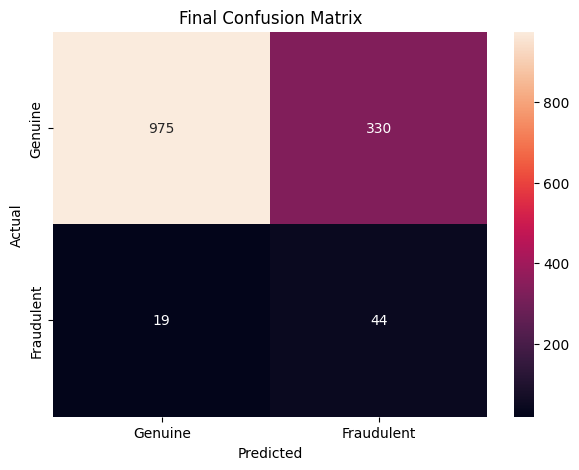

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Genuine', 'Fraudulent'],
    yticklabels=['Genuine', 'Fraudulent']
)

plt.title('Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Step 15 — ROC Curve

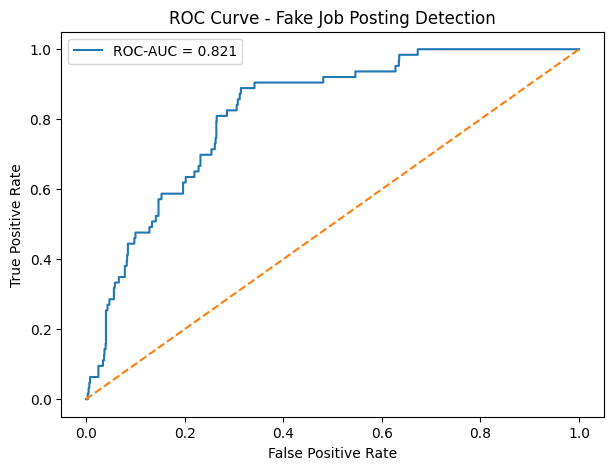

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fake Job Posting Detection')

plt.legend()

plt.show()

# Step 16 — Precision-Recall Curve

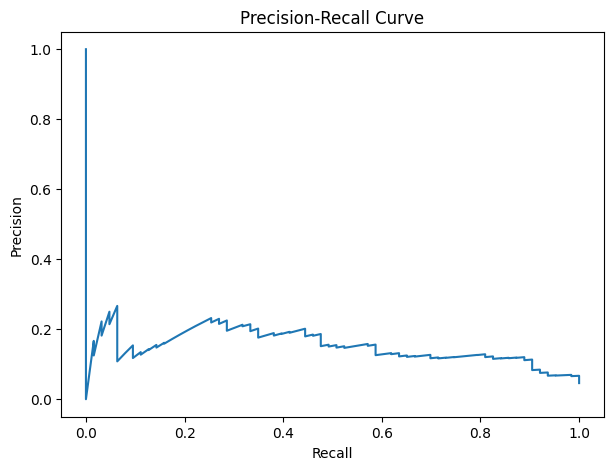

In [ ]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.show()

# Step 17 — Final business insights

## Key Business Insights

1. The dataset contains a significantly larger number of genuine job postings than fraudulent postings.

2. Fraudulent job postings represent a minority class, making class imbalance an important consideration.

3. Different job-posting characteristics can provide useful signals for identifying potentially fraudulent postings.

4. Statistical analysis helps determine whether selected categorical variables are associated with fraudulent job status.

5. Logistic Regression provides a baseline machine learning solution for binary fake-job classification.

6. Accuracy alone is not sufficient because of the class imbalance. Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix provide a more complete evaluation.

7. False negatives are particularly important because they represent fraudulent job postings that were incorrectly classified as genuine.

# Step 18 — Strategic recommendations

## Strategic Recommendations

### 1. Automated Job Screening
Recruitment platforms can use machine learning to automatically identify potentially suspicious job postings.

### 2. Multi-Signal Detection
Fraud detection should combine multiple job-posting characteristics rather than depending on a single feature.

### 3. Human Verification
High-risk postings should be reviewed by human moderators before being removed or approved.

### 4. Improve Fraud Detection Recall
Because fraudulent postings are the minority class, improving recall can help identify more fraudulent postings.

### 5. Use NLP
Future versions should analyze job titles, descriptions, requirements, company profiles, and benefits using NLP techniques.

### 6. Continuous Monitoring
The model should be monitored and retrained regularly as fraud patterns change.

### 7. User Protection
Potentially suspicious job postings can be flagged to protect job seekers.

# Step 19 — Final conclusion

## Conclusion

This project demonstrates an end-to-end Data Science workflow for Fake Job Posting Detection.

The project combines data cleaning, exploratory data analysis, advanced visualization, statistical analysis, hypothesis testing, machine learning, model evaluation, and strategic recommendations.

The dataset contains a strong class imbalance, with fraudulent job postings representing approximately 4.61% of labeled records. Therefore, model performance should be evaluated using multiple metrics rather than accuracy alone.

Logistic Regression was developed as a baseline classification model. The results provide a starting point for automated fake-job detection.

Future improvements can include Natural Language Processing, advanced machine learning algorithms, class-imbalance techniques, hyperparameter tuning, explainable AI, and deployment through a web application.